# Batch dataset: 9-condition re-render comparison + SH2/SH3 decomposition

Driver for the `batch_render_scenes.py` datasets (128 lights, conditions `env` / `env_ground`,
DC-lifted env maps). Two parts:

**A — forward re-render comparison.** Nine image sources per view:
- **GT re-renders** (GT intrinsics + GT lighting) with `ct_sh`, `ct_env` (quadrature),
  `ct_env` (GGX importance) — for `env` and `env_ground` → 6
- **Blender** renders: `env`, `env_ground` (no-shadow), `env_ground` (shadow) → 3

For **light 0** we save A / B / residual(A−B) panels (RMSE + MAE annotated) for the pairs
`ct_sh↔ct_env`, `ct_env↔ct_env(imp)`, `ct_sh↔Blender`, `ct_env↔Blender`, for both `env` and
`env_ground` (the Blender pairs on `env_ground` are done against no-shadow **and** shadow
separately). Mean±std of every pair metric over all views is reported.

**B — decomposition.** All 9 sources become datasets and are decomposed with **SH2** and **SH3**
(central `DOWNSAMPLE`, default ÷4). First 100 lights train, last 28 are the held-out
relighting val set. Per run we save: an intrinsics panel (target/recon/error + RMSE), one
relighting panel per val light (target/relit/residual + RMSE/MAE), and a `report.json`.
Everything is tracked on wandb. Final cell plots the metric means±std across views.

`ct_env` / `ct_env(imp)` decomposition is wired but disabled by default (`DECOMP_SHADERS`).

In [2]:
import sys, os, json, types
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO = Path('.').resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

try:
    import wandb
    assert hasattr(wandb, 'init')
    WANDB_OK = True
except Exception:
    _stub = types.ModuleType('wandb')
    class _Run:
        def log(self, *a, **k): pass
        def finish(self): pass
    _stub.init = lambda **kw: _Run(); _stub.log = lambda *a, **k: None; _stub.Image = lambda *a, **k: None
    sys.modules['wandb'] = wandb = _stub
    WANDB_OK = False
    print('wandb stub (metrics still saved locally)')

from raw_optimizer.dfront_ct import (
    decompose_scene, build_3dfront_dataset, load_exr, make_proxy_geometry, make_run_name,
)
from raw_renderer_gpu import shade_ct_sh, shade_ct_env, EnvMap
from raw_renderer_gpu.scene import build_sh_basis
from raw_renderer_gpu.rasterizer import _get_ggx_sh_lut

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
pd.set_option('display.width', 240)

# ── config ────────────────────────────────────────────────────────────────────
BATCH_ROOT   = Path(r'E:\3D-Front\output')
SCENE_FILTER = None            # e.g. ['00004f89']; None = all
MAX_VIEWS    = None            # cap (scene,view) pairs for testing; None = all
MAX_LIGHTS   = None            # truncate lights per view (testing); None = all
DS_ROOT      = Path('results/3dfront-batch')

DOWNSAMPLE   = 4               # central resolution reduction for decomposition
N_TRAIN      = 100             # first N lights used for training
N_VAL        = 28              # remaining lights held out for relighting
SH_ORDERS    = [2, 3]          # decomposition SH orders to compare
DECOMP_SHADERS = ['ct_sh']     # ['ct_sh','ct_env','ct_env_imp'] — env variants off by default
SPEC_SAMPLES = 128
# Generate CT re-render datasets in BOTH diffuse-Fresnel modes so we can compare:
# frOn = data uses (1-F)(1-m) (matches the always-Fresnel-ON optimizer -> inverse
# crime, recon -> 0); frOff = data uses (1-m) (deliberate model mismatch).
CT_FRESNEL_MODES = [True, False]

FORCE_RECHECK   = False        # redo part A
FORCE_DECOMPOSE = False        # redo part B

WANDB_PROJECT_A = '3dfront-rerender-compare'
WANDB_PROJECT_B = '3dfront-batch-decomposition'
WANDB_OK = False

DECOMP_BASE_CFG = {
    'n_iter': 600, 'lbfgs_max_iter': 20, 'log_every': 10,
    'lambda_tv': 1e-3, 'lambda_metallic_binarize': 1e-3,
    'tr_metallic': 'sigmoid', 'tr_roughness': 'sigmoid', 'tr_albedo': 'sigmoid',
    'init_roughness_zero': True, 'double': True,
    'wandb_max_images': 6,     # cap per-image wandb previews (scalars use all imgs)
    'diffuse_fresnel': True,   # optimizer ALWAYS Fresnel-ON (== frOn CT data + blender)
}
ENV_STRENGTH = 2.0
print(f'device={DEVICE}  wandb={"ON" if WANDB_OK else "stub"}  downsample={DOWNSAMPLE}')

c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


device=cuda  wandb=stub  downsample=4


In [3]:
# ── discovery: (scene, view) with GT dirs + Blender images + GT SH per light ───
def discover_views():
    views = []
    for sd in sorted(BATCH_ROOT.iterdir()):
        if not sd.is_dir() or sd.name.lower().startswith('backup'):
            continue
        if SCENE_FILTER and not any(sd.name.startswith(p) for p in SCENE_FILTER):
            continue
        for vd in sorted((p for p in sd.iterdir() if p.is_dir() and p.name.isdigit()),
                         key=lambda p: int(p.name)):
            acc = vd / 'accepted_setup.json'
            gdir = vd / 'ground'
            if not acc.exists() or not (gdir / 'albedo.png').exists():
                continue
            setup = json.loads(acc.read_text())
            env_e = setup.get('env'); grd_e = setup.get('env_ground')
            if not env_e or not grd_e:
                continue
            n = min(len(env_e), len(grd_e))
            if MAX_LIGHTS:
                n = min(n, MAX_LIGHTS)
            env_exr = [vd / f'env_{i}.exr' for i in range(n)]
            gnos    = [gdir / f'env_ground_noshadow_{i}.exr' for i in range(n)]
            gsha    = [gdir / f'env_ground_shadow_{i}.exr' for i in range(n)]
            if not (all(f.exists() for f in env_exr) and all(f.exists() for f in gnos)
                    and all(f.exists() for f in gsha)):
                continue
            def _sh(entries):
                out = []
                for e in entries[:n]:
                    p = Path(e['light_spec'][0]['path']); idx = p.stem.split('_')[-1]
                    out.append(np.load(p.parent / f'sh_{idx}.npy').astype(np.float32)
                               * float(e['light_spec'][0].get('strength', ENV_STRENGTH)))
                return out
            views.append(dict(
                scene=sd.name, view=int(vd.name), key=f'{sd.name[:8]}_v{vd.name}', n=n,
                env_dir=vd, ground_dir=gdir,
                blender={'env': env_exr, 'env_ground_noshadow': gnos, 'env_ground_shadow': gsha},
                sh_env=_sh(env_e), sh_ground=_sh(grd_e)))
    return views

views = discover_views()
if MAX_VIEWS:
    views = views[:MAX_VIEWS]
print(f'{len(views)} (scene, view) pair(s), {views[0]["n"] if views else 0} lights each:')
for v in views:
    print(f'  {v["key"]:20s} {v["n"]} lights')

30 (scene, view) pair(s), 128 lights each:
  00004f89_v0          128 lights
  00004f89_v1          128 lights
  00004f89_v2          128 lights
  00004f89_v3          128 lights
  00004f89_v4          128 lights
  0003d406_v0          128 lights
  0003d406_v1          128 lights
  0003d406_v2          128 lights
  0003d406_v3          128 lights
  0003d406_v4          128 lights
  00110bde_v0          128 lights
  00110bde_v1          128 lights
  00110bde_v2          128 lights
  00110bde_v3          128 lights
  00110bde_v4          128 lights
  00154c06_v0          128 lights
  00154c06_v1          128 lights
  00154c06_v2          128 lights
  00154c06_v3          128 lights
  00154c06_v4          128 lights
  0023b7d1_v0          128 lights
  0023b7d1_v1          128 lights
  0023b7d1_v2          128 lights
  0023b7d1_v3          128 lights
  0023b7d1_v4          128 lights
  002c110c_v0          128 lights
  002c110c_v1          128 lights
  002c110c_v2          128 lights
  002

In [4]:
# ── per-view renderers (full res) ──────────────────────────────────────────────
def load_gt_view(d: Path) -> dict:
    nr = np.array(Image.open(d / 'normals.png'), np.float32)
    mask = nr.sum(-1) > 0
    n = nr / 255 * 2 - 1
    n /= np.maximum(np.linalg.norm(n, axis=-1, keepdims=True), 1e-6)
    return dict(normals=n, mask=mask,
                albedo=np.array(Image.open(d / 'albedo.png'), np.float32)[:, :, :3] / 255,
                rough=(np.array(Image.open(d / 'roughness.png'), np.float32) / 65535.)[:, :, None],
                metal=(np.array(Image.open(d / 'metallic.png'), np.float32) / 65535.)[:, :, None])

class GTRenderer:
    def __init__(self, gt):
        self.gt = gt; self.H, self.W = gt['mask'].shape
        self.mflat = gt['mask'].reshape(-1)
        n_hw, f_hw, m_hw, cam = make_proxy_geometry(gt['normals'], gt['mask'],
                                                    device=DEVICE, dtype=torch.float64)
        fm = m_hw.reshape(-1)
        self.N = n_hw.reshape(-1, 3)[fm]
        self.V = torch.nn.functional.normalize(cam.unsqueeze(0) - f_hw.reshape(-1, 3)[fm], dim=-1)
        f = lambda a: torch.from_numpy(np.ascontiguousarray(a, np.float64)).to(DEVICE).reshape(-1, a.shape[-1])[fm]
        self.A, self.R, self.M = f(gt['albedo']), f(gt['rough']), f(gt['metal'])
        self.lut = _get_ggx_sh_lut(DEVICE, n_bands=3).double()
    def _scatter(self, flat):
        out = np.zeros((self.H * self.W, 3), np.float32)
        out[self.mflat] = flat.float().cpu().numpy()
        return out.reshape(self.H, self.W, 3)
    def render(self, sh, shader, diffuse_fresnel=True):
        with torch.no_grad():
            if shader == 'ct_sh':
                sh_t = torch.from_numpy(np.asarray(sh, np.float64)).to(DEVICE)
                o = shade_ct_sh(self.V, self.N, self.A, sh_t, metallic=self.M, roughness=self.R,
                                lut=self.lut, diffuse_fresnel=diffuse_fresnel)
            else:
                img = np.maximum(build_sh_basis(EnvMap._sh_grid_dirs(64)) @ np.asarray(sh, np.float32), 0.0)
                em = EnvMap(img)
                o = shade_ct_env(self.V, self.N, self.A,
                                 torch.from_numpy(em._image_flat).to(DEVICE, torch.float64),
                                 torch.from_numpy(em._dirs).to(DEVICE, torch.float64),
                                 torch.from_numpy(em._solid_angles).to(DEVICE, torch.float64),
                                 metallic=self.M, roughness=self.R,
                                 spec_importance=(shader == 'ct_env_imp'), spec_samples=SPEC_SAMPLES,
                                 diffuse_fresnel=diffuse_fresnel)
        return self._scatter(o)

def masked_errs(A, B, mask):
    d = (A - B)[mask]
    return float(np.sqrt((d ** 2).mean())), float(np.abs(d).mean())

## A — forward re-render comparison (light 0)

In [5]:
import itertools
# ── Part A: forward-render comparison at light 0 (all outputs SAVED to disk;
# no inline images, no wandb — just progress). Two products per view:
#   1) all-vs-all similarity (confusion) matrices  -> sim_<cond>_<rmse|mae>.png
#   2) pairwise A / B / residual panels            -> pair_<cond>__<A>__vs__<B>.png
# The averaged confusion matrices are shown in the next cell.
CONDS = {
    'env':        ['ct_sh_frOn', 'ct_sh_frOff', 'ct_env', 'ct_env_imp', 'blender'],
    'env_ground': ['ct_sh_frOn', 'ct_sh_frOff', 'ct_env', 'ct_env_imp',
                   'blender_noshadow', 'blender_shadow'],
}
# specific pairs to render as A/B/residual panels (per condition)
PAIRS = {
    'env': [('ct_sh_frOn', 'ct_sh_frOff'), ('ct_sh_frOn', 'ct_env'), ('ct_env', 'ct_env_imp'),
            ('ct_sh_frOn', 'blender'), ('ct_sh_frOff', 'blender'), ('ct_env', 'blender')],
    'env_ground': [('ct_sh_frOn', 'ct_sh_frOff'), ('ct_sh_frOn', 'ct_env'), ('ct_env', 'ct_env_imp')]
                  + [(a, b) for b in ('blender_noshadow', 'blender_shadow')
                     for a in ('ct_sh_frOn', 'ct_sh_frOff', 'ct_env')],
}

def _sim_matrix(variants, mask, metric):
    labels = list(variants); M = len(labels); mat = np.zeros((M, M))
    for i, j in itertools.combinations(range(M), 2):
        d = (variants[labels[i]] - variants[labels[j]])[mask]
        val = float(np.sqrt((d ** 2).mean())) if metric == 'rmse' else float(np.abs(d).mean())
        mat[i, j] = mat[j, i] = val
    return labels, mat

def _plot_matrix(ax, labels, mat, title):
    im = ax.imshow(mat, cmap='viridis')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    thr = mat.max() * 0.6 if mat.max() > 0 else 1
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center', fontsize=7,
                    color='white' if mat[i, j] < thr else 'black')
    ax.set_title(title, fontsize=9); return im

def pair_panel(A, B, mask, nameA, nameB, title, save_path, tone=2.0):
    rmse, mae = masked_errs(A, B, mask); resid = np.abs(A - B).mean(-1) * mask
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
    ax[0].imshow(np.clip(A / tone, 0, 1)); ax[0].set_title(nameA, fontsize=9)
    ax[1].imshow(np.clip(B / tone, 0, 1)); ax[1].set_title(nameB, fontsize=9)
    im = ax[2].imshow(resid, cmap='inferno'); ax[2].set_title(f'|A-B|  RMSE={rmse:.4f}  MAE={mae:.4f}', fontsize=9)
    plt.colorbar(im, ax=ax[2], fraction=0.046)
    for a in ax: a.axis('off')
    fig.suptitle(title, fontsize=10); plt.tight_layout()
    fig.savefig(save_path, dpi=80); plt.close(fig)

SIM_ACC = {c: {'rmse': [], 'mae': []} for c in CONDS}
for _vi, v in enumerate(views):
    out_dir = DS_ROOT / 'compare' / v['key']; out_dir.mkdir(parents=True, exist_ok=True)
    cache = out_dir / 'sim_matrices.json'
    if cache.exists() and not FORCE_RECHECK:
        d = json.loads(cache.read_text())
        for c in CONDS:
            SIM_ACC[c]['rmse'].append(np.array(d[c]['rmse'])); SIM_ACC[c]['mae'].append(np.array(d[c]['mae']))
        print(f'[{_vi+1}/{len(views)}] {v["key"]}: cached'); continue
    print(f'[{_vi+1}/{len(views)}] {v["key"]}: comparing (saving matrices + pair panels to {out_dir}) ...', flush=True)
    store = {}
    for cond, gt_dir, sh_list, bl in [
        ('env', v['env_dir'], v['sh_env'], {'blender': 'env'}),
        ('env_ground', v['ground_dir'], v['sh_ground'],
         {'blender_noshadow': 'env_ground_noshadow', 'blender_shadow': 'env_ground_shadow'}),
    ]:
        gt = load_gt_view(gt_dir); r = GTRenderer(gt); mask = gt['mask']; sh0 = sh_list[0]
        var = {'ct_sh_frOn':  r.render(sh0, 'ct_sh', diffuse_fresnel=True),
               'ct_sh_frOff': r.render(sh0, 'ct_sh', diffuse_fresnel=False),
               'ct_env': r.render(sh0, 'ct_env'), 'ct_env_imp': r.render(sh0, 'ct_env_imp')}
        for lbl, bk in bl.items():
            var[lbl] = load_exr(v['blender'][bk][0]).astype(np.float32)
        var = {k: var[k] for k in CONDS[cond]}
        store[cond] = {}
        for metric in ('rmse', 'mae'):
            labels, mat = _sim_matrix(var, mask, metric)
            fig, ax = plt.subplots(figsize=(1.0 * len(labels) + 2.5, 1.0 * len(labels) + 2))
            _plot_matrix(ax, labels, mat, f'{v["key"]} {cond} {metric.upper()} (light 0)')
            plt.colorbar(ax.images[0], ax=ax, fraction=0.046); plt.tight_layout()
            fig.savefig(out_dir / f'sim_{cond}_{metric}.png', dpi=80); plt.close(fig)
            SIM_ACC[cond][metric].append(mat); store[cond][metric] = mat.tolist()
        for nA, nB in PAIRS[cond]:
            pair_panel(var[nA], var[nB], mask, nA, nB,
                       f'{v["key"]}  {cond}  {nA} vs {nB}  (light 0)',
                       out_dir / f'pair_{cond}__{nA}__vs__{nB}.png')
    cache.write_text(json.dumps(store, indent=1))
print('done comparing.')

[1/30] 00004f89_v0: cached
[2/30] 00004f89_v1: cached
[3/30] 00004f89_v2: cached
[4/30] 00004f89_v3: cached
[5/30] 00004f89_v4: cached
[6/30] 0003d406_v0: cached
[7/30] 0003d406_v1: cached
[8/30] 0003d406_v2: cached
[9/30] 0003d406_v3: cached
[10/30] 0003d406_v4: cached
[11/30] 00110bde_v0: cached
[12/30] 00110bde_v1: cached
[13/30] 00110bde_v2: cached
[14/30] 00110bde_v3: cached
[15/30] 00110bde_v4: cached
[16/30] 00154c06_v0: cached
[17/30] 00154c06_v1: cached
[18/30] 00154c06_v2: cached
[19/30] 00154c06_v3: cached
[20/30] 00154c06_v4: cached
[21/30] 0023b7d1_v0: cached
[22/30] 0023b7d1_v1: cached
[23/30] 0023b7d1_v2: cached
[24/30] 0023b7d1_v3: cached
[25/30] 0023b7d1_v4: cached
[26/30] 002c110c_v0: comparing (saving matrices + pair panels to results\3dfront-batch\compare\002c110c_v0) ...
[27/30] 002c110c_v1: comparing (saving matrices + pair panels to results\3dfront-batch\compare\002c110c_v1) ...
[28/30] 002c110c_v2: comparing (saving matrices + pair panels to results\3dfront-batc


=== env: mean RMSE over 30 view(s) ===
             ct_sh_frOn  ct_sh_frOff  ct_env  ct_env_imp  blender
ct_sh_frOn       0.0000       0.0359  0.0249      0.0135   0.0294
ct_sh_frOff      0.0359       0.0000  0.0387      0.0279   0.0489
ct_env           0.0249       0.0387  0.0000      0.0202   0.0372
ct_env_imp       0.0135       0.0279  0.0202      0.0000   0.0313
blender          0.0294       0.0489  0.0372      0.0313   0.0000


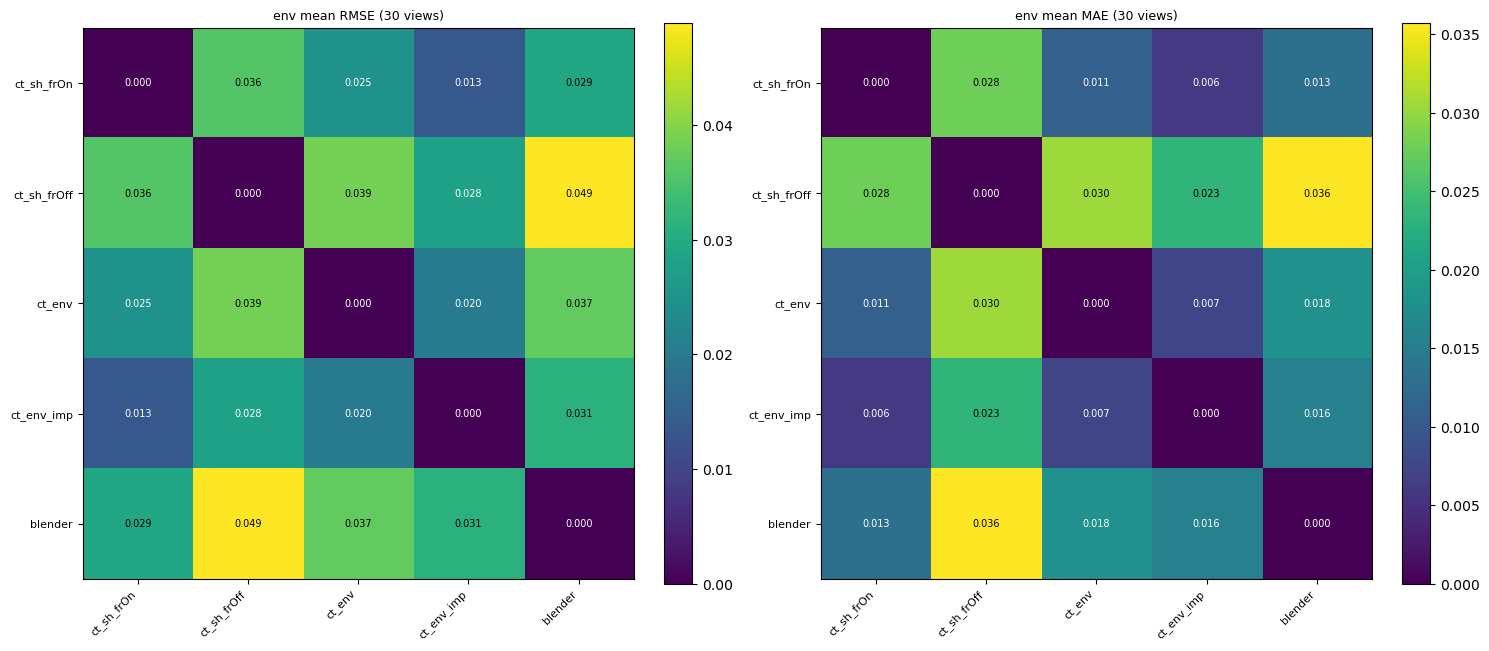


=== env_ground: mean RMSE over 30 view(s) ===
                  ct_sh_frOn  ct_sh_frOff  ct_env  ct_env_imp  blender_noshadow  blender_shadow
ct_sh_frOn            0.0000       0.0824  0.4449      0.0753            0.0777          0.1525
ct_sh_frOff           0.0824       0.0000  0.4120      0.0302            0.0388          0.1497
ct_env                0.4449       0.4120  0.0000      0.4035            0.4074          0.4996
ct_env_imp            0.0753       0.0302  0.4035      0.0000            0.0403          0.1431
blender_noshadow      0.0777       0.0388  0.4074      0.0403            0.0000          0.1266
blender_shadow        0.1525       0.1497  0.4996      0.1431            0.1266          0.0000


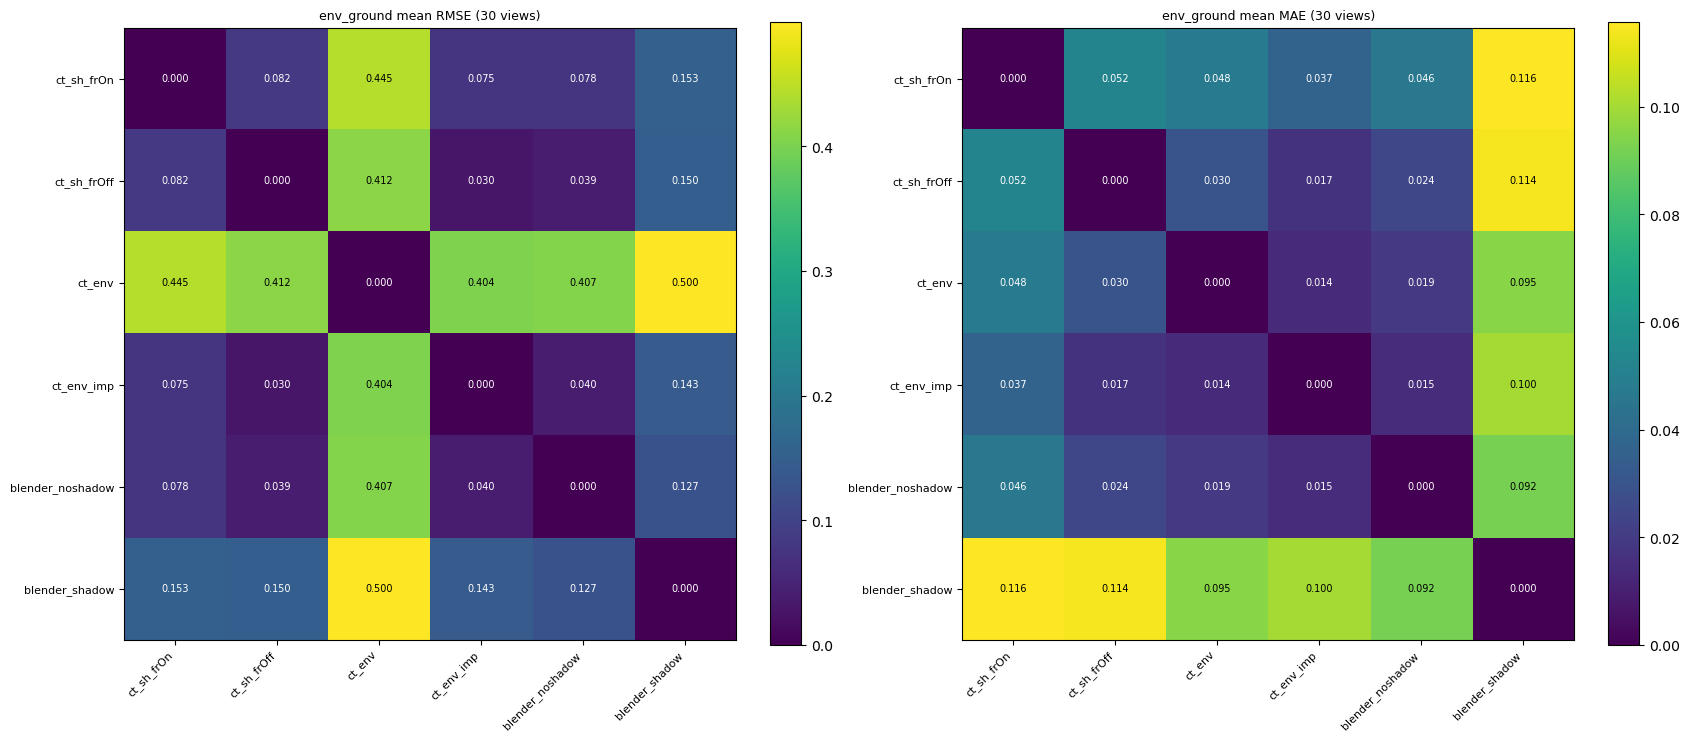

In [6]:
# ── averaged similarity (confusion) matrices over views, separate env / env_ground ──
for cond, labels in CONDS.items():
    if not SIM_ACC[cond]['rmse']:
        continue
    n = len(SIM_ACC[cond]['rmse'])
    avg = {m: np.mean(SIM_ACC[cond][m], axis=0) for m in ('rmse', 'mae')}
    print(f'\n=== {cond}: mean RMSE over {n} view(s) ===')
    print(pd.DataFrame(avg['rmse'], index=labels, columns=labels).round(4).to_string())
    fig, ax = plt.subplots(1, 2, figsize=(2.0 * (1.0 * len(labels) + 2.5), 1.0 * len(labels) + 2))
    for a, m in zip(ax, ('rmse', 'mae')):
        _plot_matrix(a, labels, avg[m], f'{cond} mean {m.upper()} ({n} views)')
        plt.colorbar(a.images[0], ax=a, fraction=0.046)
    plt.tight_layout(); fig.savefig(DS_ROOT / 'compare' / f'AVG_{cond}.png', dpi=90); plt.show()

## B — build datasets (run locally, then upload)

Builds every self-contained dataset dir under `DS_ROOT/datasets/` (all pre-reduced to the ÷DOWNSAMPLE grid, GT SH embedded). This is the only step to run on your machine before uploading — decomposition is a SEPARATE step (Part C below, or `run_decomposition.py` on the VM).

In [7]:
import shutil
# ── shared: write GT maps (already at target res) as the dataset's GT PNGs ─────
def _write_gt_maps(out_dir, gt):
    '''gt: dict of float maps (normals,mask,albedo,rough,metal) at target res.
    Re-encodes with the zero-normal background preserved so load_scene's mask
    (normals.sum>0) matches. Identical encoding for CT and blender datasets.'''
    def _wpng(a, p, mode16=False):
        a = a.squeeze()
        if mode16:
            Image.fromarray((np.clip(a, 0, 1) * 65535).astype(np.uint16)).save(p)
        elif a.ndim == 2:
            Image.fromarray((np.clip(a, 0, 1) * 255).astype(np.uint8)).save(p)
        else:
            Image.fromarray((np.clip(a[:, :, :3], 0, 1) * 255).astype(np.uint8)).save(p)
    nrm = ((gt['normals'] + 1) / 2 * 255).astype(np.uint8)
    nrm[~gt['mask']] = 0
    Image.fromarray(nrm).save(out_dir / 'normals.png')
    _wpng(gt['albedo'], out_dir / 'albedo.png')
    _wpng(gt['rough'], out_dir / 'roughness.png', mode16=True)
    _wpng(gt['metal'], out_dir / 'metallic.png', mode16=True)

def _stride_gt(gt, ds):
    if ds > 1:
        gt = {k: (np.ascontiguousarray(v[::ds, ::ds]) if isinstance(v, np.ndarray) else v)
              for k, v in gt.items()}
    return gt

def build_ct_dataset(gt_dir, out_dir, sh_list, shader, diffuse_fresnel=True):
    '''Render GT maps under all lights with `shader` at the DOWNSAMPLEd
    resolution; write a self-contained exr-variant dataset dir (decomposed with
    downsample=1). `diffuse_fresnel` chooses the DATA diffuse model:
    True = (1-F)(1-m) (shader default), False = (1-m).'''
    ds = DOWNSAMPLE
    cfg_p = out_dir / 'config.json'
    if (cfg_p.exists() and json.loads(cfg_p.read_text()).get('prereduced_downsample') == ds
            and json.loads(cfg_p.read_text()).get('diffuse_fresnel') == diffuse_fresnel):
        return
    shutil.rmtree(out_dir, ignore_errors=True)
    out_dir.mkdir(parents=True, exist_ok=True)
    gt = _stride_gt(load_gt_view(gt_dir), ds)
    _write_gt_maps(out_dir, gt)
    r = GTRenderer(gt)
    for i, sh in enumerate(sh_list):
        np.save(out_dir / f'light_{i:03d}.npy',
                r.render(sh, shader, diffuse_fresnel=diffuse_fresnel).astype(np.float32))
        np.save(out_dir / f'sh_{i:03d}.npy', np.asarray(sh, np.float32))
    cfg_p.write_text(json.dumps(
        {'variant': 'exr', 'n_lights': len(sh_list), 'light_type': 'light',
         'ct_shader': shader, 'src': str(gt_dir), 'prereduced_downsample': ds,
         'diffuse_fresnel': diffuse_fresnel}, indent=1))

def build_blender_dataset(v, cond, out_dir):
    '''Blender exr images → self-contained exr-variant dataset dir, PRE-REDUCED
    to the DOWNSAMPLEd grid (decomposed with downsample=1) so the whole
    datasets/ folder is small to upload. GT SH scaled by the exr normalisation.'''
    ds = DOWNSAMPLE
    cfg_p = out_dir / 'config.json'
    if cfg_p.exists() and json.loads(cfg_p.read_text()).get('prereduced_downsample') == ds:
        return
    shutil.rmtree(out_dir, ignore_errors=True)
    stem = {'env': 'env', 'env_ground_noshadow': 'env_ground_noshadow',
            'env_ground_shadow': 'env_ground_shadow'}[cond]
    src = v['env_dir'] if cond == 'env' else v['ground_dir']
    build_3dfront_dataset(src, out_dir, variant='exr', lighting=stem)   # full-res intermediate
    cfg = json.loads(cfg_p.read_text())
    exr_scale = float(cfg.get('exr_scale', 1.0) or 1.0)
    sh_list = v['sh_env'] if cond == 'env' else v['sh_ground']
    # trim extras (build_3dfront_dataset globs every on-disk exr; MAX_LIGHTS may cap sh_list)
    for f in sorted(out_dir.glob('light_*.npy'))[len(sh_list):]:
        f.unlink(); f.with_name(f.stem + '_preview.png').unlink(missing_ok=True)
    # stride light npy + re-encode GT to the reduced grid, drop full-res previews
    for f in sorted(out_dir.glob('light_*.npy')):
        if ds > 1:
            np.save(f, np.ascontiguousarray(np.load(f)[::ds, ::ds]))
    for f in out_dir.glob('light_*_preview.png'):
        f.unlink()
    _write_gt_maps(out_dir, _stride_gt(load_gt_view(out_dir), ds))
    for i, sh in enumerate(sh_list):
        np.save(out_dir / f'sh_{i:03d}.npy', (np.asarray(sh, np.float32) / exr_scale))
    cfg['prereduced_downsample'] = ds
    cfg_p.write_text(json.dumps(cfg, indent=1))

# dataset specs: CT re-renders (each shader × both diffuse-Fresnel modes) + blender
def dataset_specs(v):
    specs = []
    for cond, gt_dir, sh_list in [('env', v['env_dir'], v['sh_env']),
                                  ('env_ground', v['ground_dir'], v['sh_ground'])]:
        for shader in ('ct_sh', 'ct_env', 'ct_env_imp'):
            for fr in CT_FRESNEL_MODES:
                frtag = 'frOn' if fr else 'frOff'
                specs.append((f'ct-{shader}-{frtag}_{cond}',
                              lambda o, g=gt_dir, s=sh_list, sh=shader, f=fr:
                                  build_ct_dataset(g, o, s, sh, diffuse_fresnel=f)))
    for cond in ('env', 'env_ground_noshadow', 'env_ground_shadow'):
        specs.append((f'blender_{cond}', lambda o, vv=v, c=cond: build_blender_dataset(vv, c, o)))
    return specs

print(f'{len(dataset_specs(views[0]))} conditions per view:')
for name, _ in dataset_specs(views[0]):
    print('  ', name)

15 conditions per view:
   ct-ct_sh-frOn_env
   ct-ct_sh-frOff_env
   ct-ct_env-frOn_env
   ct-ct_env-frOff_env
   ct-ct_env_imp-frOn_env
   ct-ct_env_imp-frOff_env
   ct-ct_sh-frOn_env_ground
   ct-ct_sh-frOff_env_ground
   ct-ct_env-frOn_env_ground
   ct-ct_env-frOff_env_ground
   ct-ct_env_imp-frOn_env_ground
   ct-ct_env_imp-frOff_env_ground
   blender_env
   blender_env_ground_noshadow
   blender_env_ground_shadow


In [8]:
# ── build all datasets (this is the "prepare on my machine" step) ─────────────
built = 0
for _vi, v in enumerate(views):
    specs = dataset_specs(v)
    for ds_name, builder in specs:
        builder(DS_ROOT / 'datasets' / v['key'] / ds_name)
        built += 1
    print(f'[{_vi+1}/{len(views)}] {v["key"]}: {len(specs)} datasets ready', flush=True)
print(f'\nDONE: {built} dataset dir(s) under {DS_ROOT / "datasets"}')
print('Upload that folder to the VM and run:')
print('  python run_decomposition.py --datasets_root <uploaded>/datasets '
      '--runs_root <out>/runs --sh_orders 2 3 --n_train {} --n_val {}'.format(N_TRAIN, N_VAL))

[1/30] 00004f89_v0: 15 datasets ready
[2/30] 00004f89_v1: 15 datasets ready
[3/30] 00004f89_v2: 15 datasets ready
[4/30] 00004f89_v3: 15 datasets ready
[5/30] 00004f89_v4: 15 datasets ready
[6/30] 0003d406_v0: 15 datasets ready
[7/30] 0003d406_v1: 15 datasets ready
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v2\blender_env
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v2\blender_env_ground_noshadow
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v2\blender_env_ground_shadow
[8/30] 0003d406_v2: 15 datasets ready
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v3\blender_env
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v3\blender_env_ground_noshadow
Built 'exr' sun dataset: 128 images -> results\3dfront-batch\datasets\0003d406_v3\blender_env_ground_shadow
[9/30] 0003d406_v3: 15 datasets ready
Built 'exr' sun dataset: 128 image

## C — decompose (OPTIONAL local run)

For quick local tests only. On the VM, run `run_decomposition.py` on the uploaded `datasets/` folder instead (resumable, wandb logging). Skip this cell if you're decomposing on the VM.

In [ ]:
# ── intrinsics + relighting plots from a finished run dir ──────────────────────
def save_intrinsics_plot(run_dir, m, save_path):
    gt = Path(m['scene'])
    panels = [('albedo GT', gt / 'albedo.png', None),
              ('albedo est', run_dir / 'albedo_scaled.png', None),
              ('albedo err', run_dir / 'albedo_err.npy', f"RMSE={m['albedo_rmse']:.3f}"),
              ('rough GT', gt / 'roughness.png', None),
              ('rough est', run_dir / 'roughness_est.png', None),
              ('rough err', run_dir / 'roughness_err.npy', f"MAE={m['roughness_err_mean']:.3f}"),
              ('metal GT', gt / 'metallic.png', None),
              ('metal est', run_dir / 'metallic_est.png', None),
              ('metal err', run_dir / 'metallic_err.npy', f"MAE={m['metallic_err_mean']:.3f}")]
    fig, ax = plt.subplots(3, 3, figsize=(9.5, 9.5))
    for a, (t, p, sub) in zip(ax.flat, panels):
        if Path(p).exists():
            im = np.load(p) if str(p).endswith('.npy') else np.array(Image.open(p))
            if str(p).endswith('.npy'):
                im = im.squeeze()
                if im.ndim == 3 and im.shape[-1] == 3:
                    im = im.mean(-1)
            a.imshow(im, cmap='gray' if im.ndim == 2 else None)
        a.set_title(t + (f'\n{sub}' if sub else ''), fontsize=8); a.axis('off')
    fig.suptitle(run_dir.name[:70], fontsize=8); plt.tight_layout()
    fig.savefig(save_path, dpi=80); plt.close(fig)

def save_relight_plots(run_dir, m, ds_dir, downsample):
    '''One target/relit/residual panel per val light (saved to run_dir/relight/plots).'''
    keys = m.get('relight_keys', [])
    rmses, maes = m.get('relight_rmse_per_light', []), m.get('relight_mae_per_light', [])
    pdir = run_dir / 'relight' / 'plots'; pdir.mkdir(parents=True, exist_ok=True)
    for k, key in enumerate(keys):
        relit_p = run_dir / 'relight' / f'relit_{key}.npy'
        tgt_p = ds_dir / f'{key}.npy'
        if not relit_p.exists() or not tgt_p.exists():
            continue
        relit = np.load(relit_p)
        tgt = np.load(tgt_p)[::downsample, ::downsample]
        resid = np.abs(relit - tgt).mean(-1)
        fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
        ax[0].imshow(np.clip(tgt / 2, 0, 1)); ax[0].set_title(f'target {key}', fontsize=8)
        ax[1].imshow(np.clip(relit / 2, 0, 1)); ax[1].set_title('relit (est intrinsics + GT light)', fontsize=8)
        im = ax[2].imshow(resid, cmap='inferno')
        rm = rmses[k] if k < len(rmses) else float('nan'); ma = maes[k] if k < len(maes) else float('nan')
        ax[2].set_title(f'residual  RMSE={rm:.4f}  MAE={ma:.4f}', fontsize=8)
        plt.colorbar(im, ax=ax[2], fraction=0.046)
        for a in ax: a.axis('off')
        plt.tight_layout(); fig.savefig(pdir / f'relight_{key}.png', dpi=80); plt.close(fig)

In [ ]:
# ── Part C (OPTIONAL, local): decompose the built datasets. On the VM use
# run_decomposition.py instead — it consumes the same DS_ROOT/datasets folder. ──
DECOMP_ROWS = []
_ds_root = DS_ROOT / 'datasets'
_items = sorted((vd.name, dd) for vd in _ds_root.iterdir() if vd.is_dir()
                for dd in sorted(vd.iterdir()) if dd.is_dir() and (dd / 'config.json').exists())
for view_key, ds_dir in _items:
    ds_name = ds_dir.name
    _dcfg = json.loads((ds_dir / 'config.json').read_text())
    eff_ds = 1 if _dcfg.get('prereduced_downsample', 0) > 1 else DOWNSAMPLE
    for order in SH_ORDERS:
        for shader in DECOMP_SHADERS:
            cfg = dict(DECOMP_BASE_CFG)
            cfg.update(shader={'ct_sh': 'ct_sh', 'ct_env': 'ct_env', 'ct_env_imp': 'ct_env'}[shader],
                       sh_order=order, downsample=eff_ds,
                       n_images=N_TRAIN + N_VAL, val_images=N_VAL)
            if shader == 'ct_env_imp':
                cfg['spec_importance'] = True; cfg['spec_samples'] = SPEC_SAMPLES
            tag = f'{view_key}__{ds_name}__{shader}_SH{order}_ds{DOWNSAMPLE}_N{N_TRAIN}'
            out_dir = DS_ROOT / 'runs' / tag
            if (out_dir / 'metrics.json').exists() and not FORCE_DECOMPOSE:
                m = json.loads((out_dir / 'metrics.json').read_text()); print(f'{tag}: cached')
            else:
                m = decompose_scene(ds_dir, out_dir, cfg_overrides=cfg, device=DEVICE,
                                    wandb_project=WANDB_PROJECT_B)
                save_intrinsics_plot(out_dir, m, out_dir / 'intrinsics.png')
                save_relight_plots(out_dir, m, ds_dir, eff_ds)
                (out_dir / 'report.json').write_text(json.dumps({
                    'view': view_key, 'dataset': ds_name, 'decomp_shader': shader, 'sh_order': order,
                    'albedo_rmse': m['albedo_rmse'], 'albedo_mae': m.get('albedo_mae'),
                    'roughness_mae': m['roughness_err_mean'], 'metallic_mae': m['metallic_err_mean'],
                    'train_recon_rmse': m['recon_rmse'], 'train_recon_mae': m.get('recon_mae'),
                    'val_relight_rmse': m.get('relight_rmse'), 'val_relight_mae': m.get('relight_mae'),
                    'final_loss': m['final_loss'], 'n_train': m.get('n_train_images'),
                    'n_val': m.get('n_val_images')}, indent=1))
            DECOMP_ROWS.append(dict(
                view=view_key, dataset=ds_name, shader=shader, sh_order=order,
                albedo_rmse=m['albedo_rmse'], albedo_mae=m.get('albedo_mae'),
                roughness_mae=m['roughness_err_mean'], metallic_mae=m['metallic_err_mean'],
                train_recon_rmse=m['recon_rmse'], val_relight_rmse=m.get('relight_rmse'),
                val_relight_mae=m.get('relight_mae'), final_loss=m['final_loss']))

df_dec = pd.DataFrame(DECOMP_ROWS)
if len(df_dec):
    df_dec.to_csv(DS_ROOT / 'decomposition_summary.csv', index=False)
    print('\n', df_dec.groupby(['dataset', 'sh_order'])[
        ['albedo_rmse', 'roughness_mae', 'metallic_mae', 'train_recon_rmse', 'val_relight_rmse']
    ].mean().round(4).to_string())

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\felix\_netrc.


  [val] holding out last 28 images for relighting (100 train images)


wandb: Currently logged in as: flaarmann (adlr-latents) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [init]          loss=1.419e-01  data=1.416e-01  metallic=0.500  roughness=0.100
  [   0]    1.2s  loss=4.997e-04  data=1.747e-04  metallic=0.501  roughness=0.100


KeyboardInterrupt: 

wandb: WARNING Tried to log to step -1 that is less than the current step 0. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


## Final: metrics across views (mean ± std)

In [ ]:
if len(df_dec):
    metrics = ['albedo_rmse', 'albedo_mae', 'roughness_mae', 'metallic_mae',
               'train_recon_rmse', 'val_relight_rmse', 'val_relight_mae']
    g = df_dec.groupby(['dataset', 'sh_order'])
    mean, std = g[metrics].mean(), g[metrics].std()
    labels = [f'{d}\nSH{o}' for d, o in mean.index]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(max(10, len(labels) * 0.5), 3 * len(metrics)))
    x = np.arange(len(labels))
    for ax, met in zip(axes, metrics):
        ax.bar(x, mean[met].values, yerr=std[met].fillna(0).values, capsize=2)
        ax.set_ylabel(met, fontsize=9); ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print('\nfull mean±std table:')
    combo = mean.round(4).astype(str) + ' ± ' + std.fillna(0).round(4).astype(str)
    print(combo.to_string())